In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    finalNumber: int

In [5]:
def adder(state: AgentState) -> AgentState:
    """Add the two numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtract number2 from number1"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

In [12]:
def decision_node(state: AgentState) -> str:
    """This node will choose the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"

In [13]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decision_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
    )

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

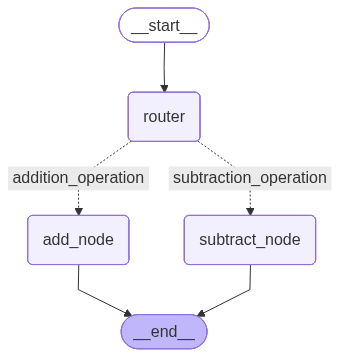

In [14]:
app

In [15]:
initial_state1 = AgentState(number1 = 15, operation="-", number2 = 5)
print(app.invoke(initial_state1))

{'number1': 15, 'operation': '-', 'number2': 5, 'finalNumber': 10}
